# OLAP Data Analysis

This notebook applies classic **OLAP (Online Analytical Processing)** operations to the shipment dataset.

| Operation | Description |
|---|---|
| **Slice** | Filter rows on a single dimension (e.g., Warehouse A only) |
| **Dice** | Filter rows on multiple dimensions simultaneously |
| **Roll-Up** | Aggregate (group-by + mean/sum) across a dimension |
| **Drill-Down** | Narrow from a high-level group into a specific subset |
| **Pivot** | Cross-tabulate two dimensions with an aggregated metric |

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [2]:
df = pd.read_csv("Train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


## 3. Data Overview

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.0 MB


,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


## 4. Slice

Filter along a **single dimension** — equivalent to fixing one face of the OLAP cube.

### 4.1 Slice — Warehouse Block A

In [4]:
slice_warehouse_A = df[df['Warehouse_block'] == 'A']
slice_warehouse_A.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
8,9,A,Flight,3,4,150,3,low,F,11,1861,1
14,15,A,Flight,4,3,152,3,low,M,43,1009,1
20,21,A,Ship,3,3,161,2,medium,F,38,1521,1
26,27,A,Ship,4,1,172,3,high,F,24,1066,1


### 4.2 Slice — On-Time Deliveries Only

In [5]:
slice_delivery = df[df['Reached.on.Time_Y.N'] == 1]
slice_delivery.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


## 5. Dice

Filter along **multiple dimensions simultaneously** — a sub-cube of the data.

In [6]:
dice_data = df[
    (df['Warehouse_block'] == 'A') &
    (df['Mode_of_Shipment'] == 'Flight') &
    (df['Product_importance'] == 'high')
]

dice_data.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
140,141,A,Flight,4,4,264,3,high,M,59,2020,1
824,825,A,Flight,3,1,142,2,high,M,18,1428,1
830,831,A,Flight,4,4,201,3,high,F,7,2644,1
956,957,A,Flight,4,1,208,7,high,F,65,2674,1
1112,1113,A,Flight,5,1,222,3,high,M,21,2351,1


## 6. Roll-Up

Aggregate metrics by summarising over a dimension — moving **up** the hierarchy.

### 6.1 Roll-Up by Warehouse Block

In [7]:
rollup_warehouse = df.groupby('Warehouse_block').agg({
    'Cost_of_the_Product': 'mean',
    'Discount_offered':    'mean',
    'Weight_in_gms':       'mean',
    'Reached.on.Time_Y.N': 'mean'
})

rollup_warehouse

,Cost_of_the_Product,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
Warehouse_block,,,,
A,208.767594,13.222586,3615.448991,0.586470
B,212.159302,13.187125,3635.701037,0.602291
C,211.191489,13.399891,3641.331151,0.596836
D,210.907852,13.093784,3628.846783,0.597601
F,209.077196,13.668031,3641.387616,0.598472


### 6.2 Roll-Up by Shipment Mode — Delivery Rate

In [8]:
rollup_shipment = df.groupby('Mode_of_Shipment')['Reached.on.Time_Y.N'].mean()
rollup_shipment

Mode_of_Shipment
Flight    0.601576
Road      0.588068
Ship      0.597561
Name: Reached.on.Time_Y.N, dtype: float64

### 6.3 Roll-Up — Delivery Rate by Warehouse

In [9]:
df.groupby('Warehouse_block')['Reached.on.Time_Y.N'].mean()

Warehouse_block
A    0.586470
B    0.602291
C    0.596836
D    0.597601
F    0.598472
Name: Reached.on.Time_Y.N, dtype: float64

## 7. Roll-Up Visualisations

### 7.1 Warehouse Distribution — Pie Chart

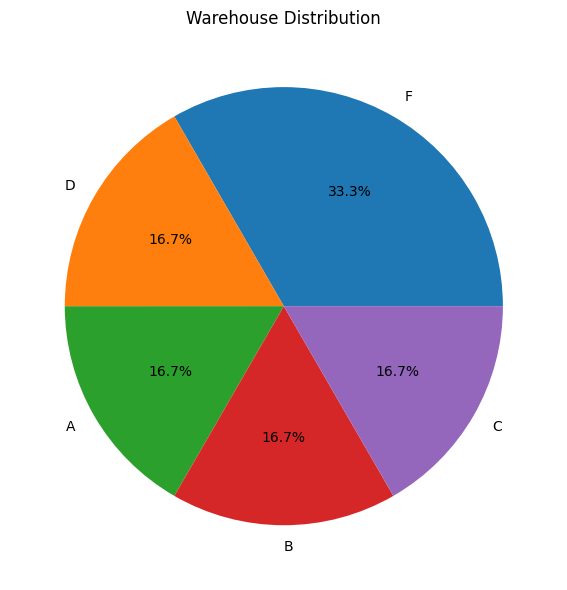

In [10]:
plt.figure(figsize=(6, 6))
plt.pie(
    df['Warehouse_block'].value_counts(),
    labels=df['Warehouse_block'].value_counts().index,
    autopct='%1.1f%%'
)
plt.title("Warehouse Distribution")
plt.tight_layout()
plt.show()

### 7.2 Average Product Cost by Warehouse — Line Plot

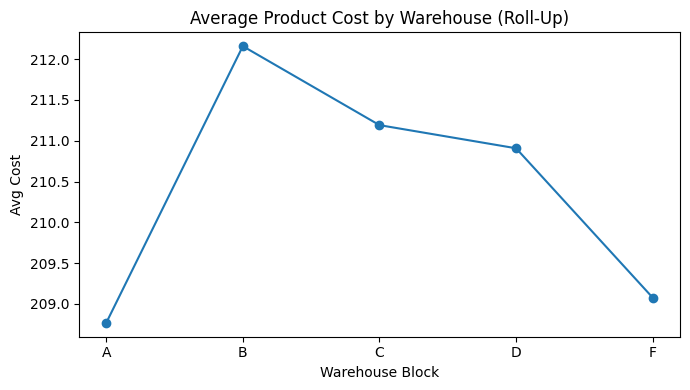

In [11]:
warehouse_cost = df.groupby('Warehouse_block')['Cost_of_the_Product'].mean()

plt.figure(figsize=(7, 4))
plt.plot(warehouse_cost.index, warehouse_cost.values, marker='o')
plt.title("Average Product Cost by Warehouse (Roll-Up)")
plt.ylabel("Avg Cost")
plt.xlabel("Warehouse Block")
plt.tight_layout()
plt.show()

## 8. Drill-Down

Start from the rolled-up view and **descend** into a specific segment for deeper inspection.

In [12]:
drilldown_A = df[df['Warehouse_block'] == 'A']
drilldown_A.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
8,9,A,Flight,3,4,150,3,low,F,11,1861,1
14,15,A,Flight,4,3,152,3,low,M,43,1009,1
20,21,A,Ship,3,3,161,2,medium,F,38,1521,1
26,27,A,Ship,4,1,172,3,high,F,24,1066,1


In [13]:
# Drill further: delivery rate per shipment mode within Warehouse A
delivery_summary = df.groupby(['Warehouse_block', 'Mode_of_Shipment'])['Reached.on.Time_Y.N'].mean()
delivery_summary

Warehouse_block  Mode_of_Shipment
A                Flight              0.585859
                 Road                0.571429
                 Ship                0.590177
B                Flight              0.597973
                 Road                0.585034
                 Ship                0.607401
C                Flight              0.623729
                 Road                0.574830
                 Ship                0.595659
D                Flight              0.599327
                 Road                0.595890
                 Ship                0.597590
F                Flight              0.601351
                 Road                0.600683
                 Ship                0.597267
Name: Reached.on.Time_Y.N, dtype: float64

## 9. Pivot — Delivery Performance Heatmap

Cross-tabulate `Warehouse_block` × `Mode_of_Shipment` with average on-time delivery rate.

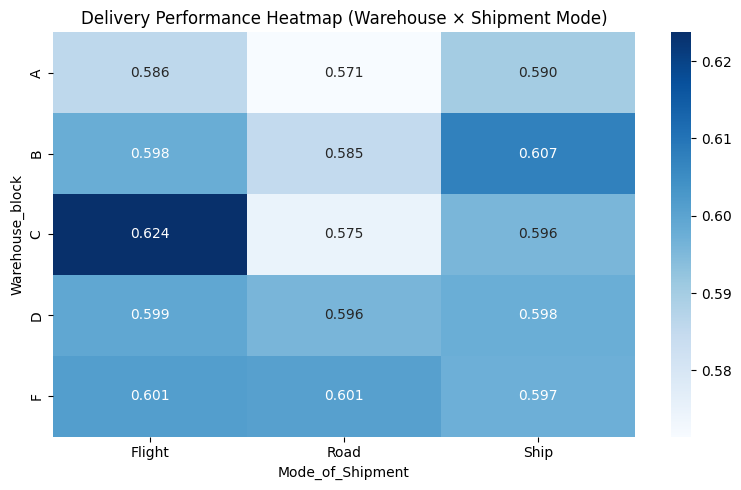

In [14]:
pivot_heatmap = df.pivot_table(
    values='Reached.on.Time_Y.N',
    index='Warehouse_block',
    columns='Mode_of_Shipment',
    aggfunc='mean'
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_heatmap, annot=True, cmap='Blues', fmt='.3f')
plt.title("Delivery Performance Heatmap (Warehouse × Shipment Mode)")
plt.tight_layout()
plt.show()